In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import openpyxl 
import preprocess_functions as ppf
import preprocess_functions.align
import preprocess_functions.plot
import preprocess_functions.pose
import preprocess_functions.roi
import preprocess_functions.segment
import re
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

## Align Neural, Behavioral, SLEAP Frames


In [2]:
sheet_path = r"20260228_paths.xlsx"
lab_drive = Path(os.environ.get("LAB_DRIVE_PATH", "Z:")) # replace with your actual lab drive path
fps = 30

In [3]:
all_sheets = ppf.align.load_sessions(sheet_path)

In [4]:
aligned_sessions = ppf.align.align_all(sheet_path=sheet_path, fps=fps, ts_col="Timestamp")



Session: 25A_20251106
beh_path  : Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251106\beh-cam_frame-id_0.csv
sleap_path: Z:Users\May\SLEAP\Miniscope_Model\20260228_2-5-A_20251031-1125\20260227_2-5-A_20251031-1125.001_2-5-A_20251106_beh-cam_0.analysis.csv
neu_path  : Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251106\miniscope_frame-id_0.csv

Session: 25A_20251113
beh_path  : Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251113\beh-cam_frame-id_3.csv
sleap_path: Z:Users\May\SLEAP\Miniscope_Model\20260228_2-5-A_20251031-1125\20260227_2-5-A_20251031-1125.002_2-5-A_20251113_beh-cam_3.analysis.csv
neu_path  : None

Session: 25A_20251114
beh_path  : Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251114\beh-cam_frame-id_0.csv
sleap_path: Z:Users\May\SLEAP\Miniscope_Model\20260228_2-5-A_20251031-1125\20260227_2-5-A_20251031-1125.003_2-5-A_20251114_beh-cam_0.analysis.csv
neu_path  : None

Session: 25A_20251118
beh_path  : Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh-cam_frame-id_1.csv
sleap_path: Z:Users\May\SLEAP\Miniscope_Mode

In [5]:
aligned_sessions

{'25A_20251106':        global_idx                           global_ts    Value  \
 0               0 2025-11-06 22:08:41.619187200+00:00      NaN   
 1               1 2025-11-06 22:08:41.652520533+00:00      NaN   
 2               2 2025-11-06 22:08:41.685853866+00:00      NaN   
 3               3 2025-11-06 22:08:41.719187199+00:00      NaN   
 4               4 2025-11-06 22:08:41.752520532+00:00      NaN   
 ...           ...                                 ...      ...   
 74706       74706 2025-11-06 22:50:11.819162298+00:00  74686.0   
 74707       74707 2025-11-06 22:50:11.852495631+00:00  74687.0   
 74708       74708 2025-11-06 22:50:11.885828964+00:00  74688.0   
 74709       74709 2025-11-06 22:50:11.919162297+00:00  74689.0   
 74710       74710 2025-11-06 22:50:11.952495630+00:00  74690.0   
 
                                    beh_ts  recorded_idx_x  beh_frame_idx  \
 0                                     NaT             NaN            NaN   
 1                      

In [6]:
len(aligned_sessions)

34

## Calculate Pose Variables

In [7]:
aligned_sessions = ppf.pose.compute_position_for_sessions(aligned_sessions, ts_col="global_ts", fps=fps)

Processing session: 25A_20251106
Processing session: 25A_20251113
Processing session: 25A_20251114
Processing session: 25A_20251118
Processing session: 25A_20251120
Processing session: 25A_20251121
Processing session: 25A_20251125
Processing session: 25B_20251106
Processing session: 25B_20251113
Processing session: 25B_20251114
Processing session: 25B_20251118
Processing session: 25B_20251120
Processing session: 25B_20251121
Processing session: 25B_20251125
Processing session: 112A_20251105
Processing session: 112A_20251113
Processing session: 112A_20251114
Processing session: 112A_20251117
Processing session: 112A_20251118
Processing session: 112A_20251119
Processing session: 112A_20251120
Processing session: 112B_20251105
Processing session: 112B_20251113
Processing session: 112B_20251114
Processing session: 112B_20251117
Processing session: 112B_20251118
Processing session: 112B_20251119
Processing session: 112B_20251120
Processing session: 112C_20251105
Processing session: 112C_202

In [8]:
for session_id, df in aligned_sessions.items():
    var_name = f"df_{session_id}"
    globals()[var_name] = df

In [9]:
df_25A_20251118

,global_idx,global_ts,Value,beh_ts,recorded_idx,beh_frame_idx,beh_dropped,neu_ts,neu_dropped,nose.x,...,beh_vid_path,mouse_id,ear_mid_x,ear_mid_y,hd_dx,hd_dy,head_dir_rad,ang_vel_rad_s,ang_vel_deg_s,ang_vel_speed
0,0,2025-11-18 21:28:59.174028800+00:00,0.0,2025-11-18 21:28:59.174028800+00:00,0.0,0.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2025-11-18 21:28:59.207362133+00:00,1.0,2025-11-18 21:28:59.205824+00:00,1.0,1.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2025-11-18 21:28:59.240695466+00:00,2.0,2025-11-18 21:28:59.239552+00:00,2.0,2.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2025-11-18 21:28:59.274028799+00:00,3.0,2025-11-18 21:28:59.272422400+00:00,3.0,3.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2025-11-18 21:28:59.307362132+00:00,4.0,2025-11-18 21:28:59.306009600+00:00,4.0,4.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55659,55659,2025-11-18 21:59:54.474010247+00:00,55651.0,2025-11-18 21:59:54.470592+00:00,55651.0,55651.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55660,55660,2025-11-18 21:59:54.507343580+00:00,55652.0,2025-11-18 21:59:54.503616+00:00,55652.0,55652.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55661,55661,2025-11-18 21:59:54.540676913+00:00,55653.0,2025-11-18 21:59:54.537305600+00:00,55653.0,55653.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55662,55662,2025-11-18 21:59:54.574010246+00:00,55654.0,2025-11-18 21:59:54.570227200+00:00,55654.0,55654.0,False,NaT,True,NaN,...,Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251118\beh...,25A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Select Arena ROIs

In [10]:
PROJECT_ROOT = Path.cwd() 

In [11]:
rois_by_session = ppf.roi.collect_rois_for_sessions(
    aligned_sessions,
    video_col="beh_vid_path",
    roi_names=["arena", "startbox_L", "startbox_R"],
    root=PROJECT_ROOT,
    folder_name="arena_rois",
)


=== 25A_20251106 ===
video: Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251106\beh-cam_0.avi
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A_20251106__arena.json
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A_20251106__startbox_L.json
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A_20251106__startbox_R.json

=== 25A_20251113 ===
video: Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251113\beh-cam_3.avi
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A_20251113__arena.json
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A_20251113__startbox_L.json
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A_20251113__startbox_R.json

=== 25A_20251114 ===
video: Z:Data\May\Cross_Maze\CCTT6-2-5-A\20251114\beh-cam_0.avi
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A_20251114__arena.json
Loaded existing ROI: c:\Users\maygc\Projects\1p_pipeline\arena_rois\25A

In [12]:
aligned_sessions_with_rois, masks_by_session = ppf.roi.add_rois_to_all_sessions(
    aligned_sessions=aligned_sessions,      # dict[session_id -> df]
    rois_by_session=rois_by_session,        # dict[session_id -> roi info]
    video_col="beh_vid_path",
    ref_x="ear_mid_x",
    ref_y="ear_mid_y",
)

25A_20251106: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25A_20251113: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25A_20251114: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25A_20251118: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25A_20251120: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25A_20251121: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25A_20251125: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25B_20251106: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25B_20251113: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25B_20251114: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
25B_20251118: added ROI features for ['arena', 'startbox_L', 'startbox

In [13]:
aligned_sessions_with_rois["112C_20251114"]

,global_idx,global_ts,Value,beh_ts,recorded_idx,beh_frame_idx,beh_dropped,neu_ts,neu_dropped,nose.x,...,in_startbox_L,startbox_L_signed_dist_px,startbox_L_dist_px,in_startbox_R,startbox_R_signed_dist_px,startbox_R_dist_px,arena_center_x,arena_center_y,dist_to_arena_center_px,dist_to_arena_center_norm
0,0,2025-11-14 22:57:26.605644800+00:00,0.0,2025-11-14 22:57:26.605644800+00:00,0.0,0.0,False,NaT,True,239.183151,...,True,66.330147,66.330147,False,-1190.289901,1190.289901,885.4,1030.6,633.561856,0.874982
1,1,2025-11-14 22:57:26.638978133+00:00,1.0,2025-11-14 22:57:26.637913600+00:00,1.0,1.0,False,NaT,True,239.198593,...,True,66.014483,66.014483,False,-1190.703867,1190.703867,885.4,1030.6,633.988214,0.875571
2,2,2025-11-14 22:57:26.672311466+00:00,2.0,2025-11-14 22:57:26.671616+00:00,2.0,2.0,False,NaT,True,238.091919,...,True,66.166901,66.166901,False,-1190.587219,1190.587219,885.4,1030.6,633.864722,0.875401
3,3,2025-11-14 22:57:26.705644799+00:00,3.0,2025-11-14 22:57:26.704614400+00:00,3.0,3.0,False,NaT,True,238.992599,...,True,67.148107,67.148107,False,-1189.861370,1189.861370,885.4,1030.6,633.094774,0.874337
4,4,2025-11-14 22:57:26.738978132+00:00,4.0,2025-11-14 22:57:26.737920+00:00,4.0,4.0,False,NaT,True,229.830750,...,True,68.981792,68.981792,False,-1189.392863,1189.392863,885.4,1030.6,632.536603,0.873566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50121,50121,2025-11-14 23:25:17.305628093+00:00,50114.0,2025-11-14 23:25:17.312371200+00:00,50114.0,50114.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,885.4,1030.6,NaN,NaN
50122,50122,2025-11-14 23:25:17.338961426+00:00,50115.0,2025-11-14 23:25:17.346112+00:00,50115.0,50115.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,885.4,1030.6,NaN,NaN
50123,50123,2025-11-14 23:25:17.372294759+00:00,50116.0,2025-11-14 23:25:17.379238400+00:00,50116.0,50116.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,885.4,1030.6,NaN,NaN
50124,50124,2025-11-14 23:25:17.405628092+00:00,50117.0,2025-11-14 23:25:17.412454400+00:00,50117.0,50117.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,885.4,1030.6,NaN,NaN


In [14]:
trials_by_session = {}

for session_id, df in aligned_sessions_with_rois.items():
    df = df.copy()

    # define arena_only (edit logic as needed)
    df["arena_only"] = df["in_arena"] & (~df["in_startbox_L"])

    trials = ppf.segment.segment_trials_gap_window(
        df,
        startbox_col="in_startbox_L",
        arena_only_col="arena_only",
        fps=30.0,
        max_gap_s=5.0,
        dwell_frames=1,
        min_trial_s=0.5,
    )

    trials_by_session[session_id] = trials
    print(f"{session_id}: {len(trials)} trials")

25A_20251106: 122 trials
25A_20251113: 100 trials
25A_20251114: 76 trials
25A_20251118: 82 trials
25A_20251120: 94 trials
25A_20251121: 112 trials
25A_20251125: 55 trials
25B_20251106: 60 trials
25B_20251113: 55 trials
25B_20251114: 50 trials
25B_20251118: 44 trials
25B_20251120: 75 trials
25B_20251121: 70 trials
25B_20251125: 61 trials
112A_20251105: 35 trials
112A_20251113: 15 trials
112A_20251114: 32 trials
112A_20251117: 26 trials
112A_20251118: 39 trials
112A_20251119: 91 trials
112A_20251120: 36 trials
112B_20251105: 27 trials
112B_20251113: 32 trials
112B_20251114: 19 trials
112B_20251117: 25 trials
112B_20251118: 22 trials
112B_20251119: 31 trials
112B_20251120: 13 trials
112C_20251105: 76 trials
112C_20251113: 53 trials
112C_20251114: 47 trials
112C_20251117: 34 trials
112C_20251118: 77 trials
112C_20251120: 74 trials


In [15]:
sb = aligned_sessions_with_rois["112C_20251114"]["in_startbox_L"].astype(bool).to_numpy()
ar = aligned_sessions_with_rois["112C_20251114"]["in_arena"].astype(bool).to_numpy()
gap = (~sb) & (~ar)

print("N:", len(aligned_sessions_with_rois["112C_20251114"]))
print("startbox True:", sb.sum())
print("arena_only True:", ar.sum())
print("gap True:", gap.sum())

print("sb & arena_only overlap (should be 0):", (sb & ar).sum())

N: 50126
startbox True: 12402
arena_only True: 30739
gap True: 6985
sb & arena_only overlap (should be 0): 0


In [16]:
sb_prev = np.r_[False, sb[:-1]]
ar_prev = np.r_[False, ar[:-1]]
gap_prev = np.r_[False, gap[:-1]]

sb_to_gap = np.where(sb_prev & gap)[0]
gap_to_ar = np.where(gap_prev & ar)[0]
ar_to_gap = np.where(ar_prev & gap)[0]
gap_to_sb = np.where(gap_prev & sb)[0]

print("sb->gap:", len(sb_to_gap))
print("gap->arena:", len(gap_to_ar))
print("arena->gap:", len(ar_to_gap))
print("gap->sb:", len(gap_to_sb))

sb->gap: 111
gap->arena: 345
arena->gap: 345
gap->sb: 110


In [17]:
out_dir = Path("aligned_sessions_with_rois")
out_dir.mkdir(parents=True, exist_ok=True)

def safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "-", str(s))

for session_id, df in aligned_sessions_with_rois.items():   # <-- NOTE: iterate aligned dict
    out_path = out_dir / f"{safe_name(session_id)}_session.csv"
    df_out = df.copy()
    df_out.to_csv(out_path, index=False)

print(f"Wrote CSVs to: {out_dir.resolve()}")

Wrote CSVs to: C:\Users\maygc\Projects\1p_pipeline\aligned_sessions_with_rois


In [18]:
# trials_by_session: dict[str, list[tuple[int,int]]]

# 1) decide how many rows you need (max # trials across sessions)
max_trials = max(len(v) for v in trials_by_session.values())

# 2) build wide table
wide = pd.DataFrame(index=range(max_trials))

for session_id, pairs in trials_by_session.items():
    # convert tuples to "(a, b)" strings (or keep tuples if you prefer)
    col = [f"({int(a)}, {int(b)})" for (a, b) in pairs]
    # pad shorter sessions with NaN so all columns have same length
    if len(col) < max_trials:
        col += [np.nan] * (max_trials - len(col))
    wide[session_id] = col

# 3) save
wide.to_csv("trials.csv", index=False) 

## Plot Trajectories

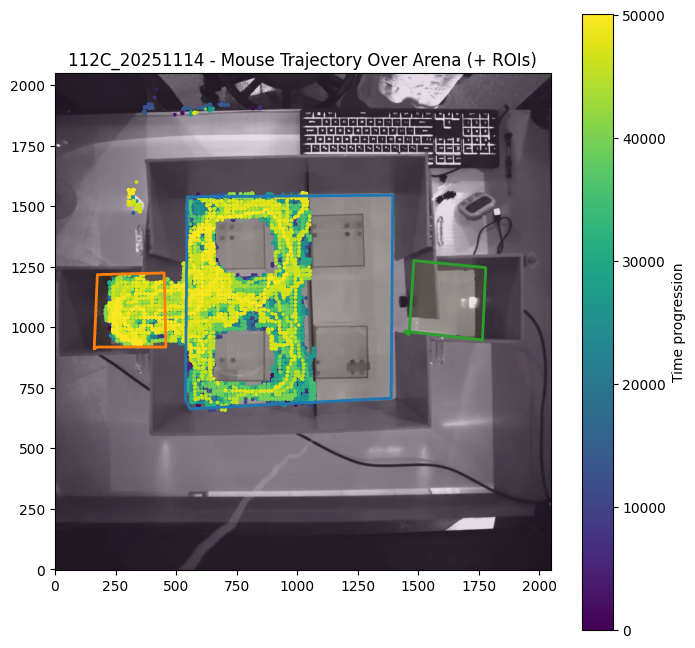

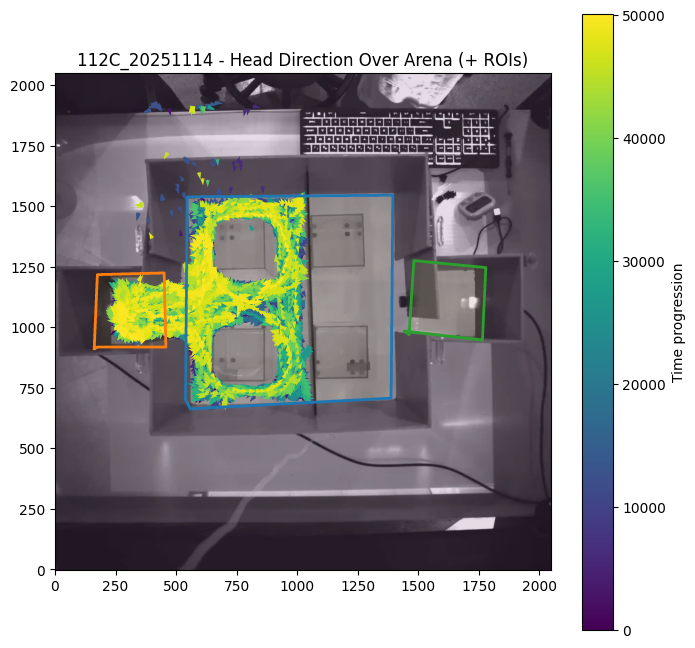

In [19]:
ppf.plot.plot_trajectory_over_arena(aligned_sessions_with_rois["112C_20251114"], masks=masks_by_session["112C_20251114"], x_col="nose.x", y_col="nose.y")
ppf.plot.plot_head_direction_over_arena(aligned_sessions_with_rois["112C_20251114"], masks=masks_by_session["112C_20251114"], x_col="ear_mid_x", y_col="ear_mid_y")

In [20]:
ppf.plot.trial_viewer(aligned_sessions_with_rois, trials_by_session, masks_by_session)


Output()

(Dropdown(description='Session:', options=('112A_20251105', '112A_20251113', '112A_20251114', '112A_20251117', '112A_20251118', '112A_20251119', '112A_20251120', '112B_20251105', '112B_20251113', '112B_20251114', '112B_20251117', '112B_20251118', '112B_20251119', '112B_20251120', '112C_20251105', '112C_20251113', '112C_20251114', '112C_20251117', '112C_20251118', '112C_20251120', '25A_20251106', '25A_20251113', '25A_20251114', '25A_20251118', '25A_20251120', '25A_20251121', '25A_20251125', '25B_20251106', '25B_20251113', '25B_20251114', '25B_20251118', '25B_20251120', '25B_20251121', '25B_20251125'), value='112A_20251105'),
 IntSlider(value=0, continuous_update=False, description='Trial', max=34),
 Output())

## Trial Stats

In [21]:
all_trial_summaries = []

for session_id, aligned_df in aligned_sessions_with_rois.items():
    trials = trials_by_session.get(session_id, [])
    if not trials:
        continue

    trial_summary = compute_trial_metrics(
        aligned_df,
        trials,
        fps=30.0,
        x_col="ear_mid_x",
        y_col="ear_mid_y",
        arena_col="in_arena",
        start_col="in_startbox_L",
    )
    trial_summary["session_id"] = session_id
    all_trial_summaries.append(trial_summary)

trial_df = pd.concat(all_trial_summaries, ignore_index=True)

NameError: name 'compute_trial_metrics' is not defined

In [ ]:
trial_df

In [ ]:
trial_df = trial_df.copy()
trial_df["session_date"] = pd.to_datetime(trial_df["session_id"], errors="coerce").dt.date
trial_df = trial_df.sort_values(["session_date", "trial"]).reset_index(drop=True)

In [ ]:
trial_df_clean = trial_df.query(
    "duration_s >= 0.5 and pos_valid_fraction >= 0.8"
).copy()

In [ ]:
day_summary = (
    trial_df_clean
    .groupby("session_date")
    .agg(
        # volume
        n_trials=("trial", "count"),

        # duration
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        iqr_duration_s=("duration_s", iqr),

        # performance / strategy
        mean_efficiency=("efficiency", "mean"),
        median_efficiency=("efficiency", "median"),
        mean_entry_latency_s=("arena_entry_latency_s", "mean"),
        median_entry_latency_s=("arena_entry_latency_s", "median"),

        # movement
        mean_speed_px_s=("mean_speed_px_s", "mean"),
        median_speed_px_s=("mean_speed_px_s", "median"),
        mean_path_len_px=("path_len_px", "mean"),
        median_path_len_px=("path_len_px", "median"),
        mean_pause_frac=("pause_fraction", "mean"),

        # spatial bias
        mean_boundary_frac=("boundary_fraction", "mean"),
        mean_center_dist_norm=("mean_center_dist_norm", "mean"),
        mean_center_frac=("center_fraction", "mean"),

        # turning (if present)
        mean_turn_deg_s=("mean_ang_speed_deg_s", "mean"),
        mean_turn_p95_deg_s=("p95_ang_speed_deg_s", "mean"),
        mean_turn_burst_frac=("turn_burst_fraction", "mean"),

        # tracking quality
        mean_pos_valid_frac=("pos_valid_fraction", "mean"),
        median_pos_valid_frac=("pos_valid_fraction", "median"),
    )
    .reset_index()
)

day_summary

In [ ]:
rewards = [23,9,21,82,17,16,6]
num_trials = day_summary["n_trials"].to_numpy()

reward_percentage = rewards[:len(num_trials)] / num_trials

print(reward_percentage)